# MNIST Multiclass Predictive Pipeline

## End-to-End Classification, Benchmarking, and Robustness Analysis

This project develops an end-to-end multiclass machine learning pipeline for handwritten digit classification using the MNIST (`mnist_784`) dataset.

The project covers:

1. Dataset loading and exploratory data analysis (EDA)
2. Stratified train, validation, and test splitting
3. Pixel normalization and preprocessing
4. Training and hyperparameter comparison of three different classifiers
5. Independent test-set evaluation
6. Comparative performance analysis
7. Class masking and out-of-distribution (OOD) evaluation
8. Inference on personally handwritten digits
9. Analysis of model limitations, robustness, and computational cost

The objective is not only to obtain high classification accuracy, but also to understand how different machine learning approaches behave under standard and challenging conditions.

# MNIST Multiclass Predictive Pipeline

## 0. Environment and Reproducibility

Before beginning the MNIST analysis, the computational environment is verified to ensure that the notebook is running with the intended Python interpreter and that all required libraries are available.

This project uses a dedicated Conda environment named `mnist-pipeline`. The environment contains the libraries required for data manipulation, visualization, classical machine learning, image processing, and neural-network development.

Because one of the benchmark models will be implemented using TensorFlow/Keras, TensorFlow and the available hardware devices are also verified at this stage.

The purpose of this section is reproducibility and troubleshooting. It does not constitute part of the predictive modeling experiment itself.

### 0.1 Environment Check

In [10]:
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
from PIL import Image
import tensorflow as tf

print("===== SYSTEM =====")
print("Architecture:", platform.machine())

print("\n===== PYTHON =====")
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\n===== CORE LIBRARIES =====")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Pillow:", Image.__version__)

print("\n===== TENSORFLOW =====")
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

===== SYSTEM =====
Architecture: arm64

===== PYTHON =====
Python executable:
/opt/miniconda3/envs/mnist-pipeline/bin/python

Python version:
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:38:15) [Clang 20.1.8 ]

===== CORE LIBRARIES =====
NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
Matplotlib: 3.11.1
Seaborn: 0.13.2
Pillow: 12.3.0

===== TENSORFLOW =====
TensorFlow: 2.18.1
Keras: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Environment Check — Interpretation

The notebook is running in the dedicated `mnist-pipeline` Conda environment, with the required libraries successfully installed. TensorFlow/Keras is also available, and the Apple Silicon GPU is detected through the Metal backend.

The environment is ready for the MNIST experiments.

### 0.2 TensorFlow Smoke Test

In [11]:
# TensorFlow Smoke Test
# This small experiment verifies that TensorFlow can create,
# compile, and train a neural network in the project environment.

import tensorflow as tf
import numpy as np

print("===== TENSORFLOW SMOKE TEST =====")
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

# Create a small synthetic binary-classification dataset.
X = np.random.rand(1000, 20).astype(np.float32)
y = np.random.randint(0, 2, size=1000)

print("\nSynthetic dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Create a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(20,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")
])

# Configure the training process.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining test model...")

history = model.fit(
    X,
    y,
    epochs=2,
    batch_size=32,
    verbose=1
)

print("\n===== SMOKE TEST COMPLETED =====")
print(
    f"Final training accuracy: "
    f"{history.history['accuracy'][-1]:.4f}"
)
print("TensorFlow neural-network training is working.")

===== TENSORFLOW SMOKE TEST =====
TensorFlow version: 2.18.1
Keras version: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Synthetic dataset:
X shape: (1000, 20)
y shape: (1000,)

Training test model...
Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5180 - loss: 0.7252
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.7046

===== SMOKE TEST COMPLETED =====
Final training accuracy: 0.5100
TensorFlow neural-network training is working.


### TensorFlow Smoke Test — Interpretation

The smoke test completed successfully, confirming that TensorFlow/Keras can train a neural network in the project environment and that GPU acceleration is available.

The synthetic dataset is used only to verify the installation; its accuracy is not relevant to the MNIST experiment.

We can now proceed to the actual dataset.

# Phase 1 — Loading and Exploratory Data Analysis (EDA)

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9. Each image has dimensions of 28 × 28 pixels.

For this project, the dataset will be represented as a matrix where each image is flattened into 784 numerical features (28 × 28). The target variable contains the corresponding digit labels.


The first step is to load the MNIST dataset and understand its structure before applying any preprocessing or training models.

This phase investigates the structure, dimensions, class distribution, pixel values, and visual representation of the dataset before preprocessing and model training.

### 1.1 Load the MNIST Dataset

MNIST is loaded with `fetch_openml()` from scikit-learn, which provides direct access to the `mnist_784` dataset and returns the images as numerical arrays that can be used directly with scikit-learn models.

The target labels are converted from strings to integers because the classification models will use the digit values (0–9) as the target classes.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

print("Loading the MNIST dataset...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto"
)

X = mnist.data
y = mnist.target.astype(np.uint8)

print("MNIST dataset loaded successfully.")

Loading the MNIST dataset...
MNIST dataset loaded successfully.


### 1.2 Dataset Structure

The next step is to verify the dimensions of the feature matrix and target vector and identify the available classes.

For MNIST, each observation should contain 784 features because each original image has 28 × 28 pixels. The target should contain one label for each image.

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nUnique classes:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

X shape: (70000, 784)
y shape: (70000,)

Number of samples: 70000
Number of features: 784

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


### 1.2 Dataset Structure — Interpretation

The dataset contains 70,000 images represented by 784 numerical features each. The 784 features correspond to the 28 × 28 pixels of each original image after flattening the two-dimensional image into a one-dimensional vector.

There are 10 target classes, representing the digits 0 through 9, with one label for each image.

The dataset structure is therefore suitable for the multiclass classification pipeline. The next step is to check whether the digit classes are reasonably balanced.

### 1.3 Class Distribution

Before training the models, we need to check how many observations are available for each digit. This helps determine whether the dataset is reasonably balanced or whether some classes are substantially underrepresented.

In [14]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Number of samples per class:")
print(class_counts)

print("\nClass proportions:")
print((class_counts / len(y)).round(4))

Number of samples per class:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64

Class proportions:
0    0.0986
1    0.1125
2    0.0999
3    0.1020
4    0.0975
5    0.0902
6    0.0982
7    0.1042
8    0.0975
9    0.0994
Name: count, dtype: float64


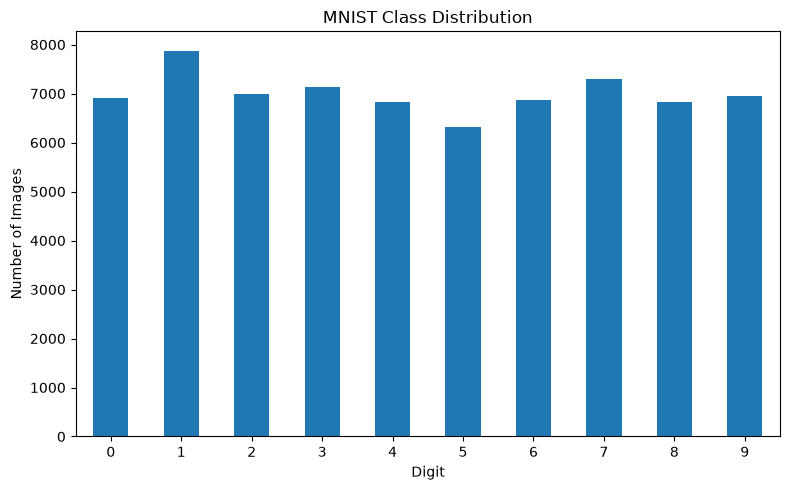

In [15]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("MNIST Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 1.3 Class Distribution — Interpretation

The 10 classes are reasonably balanced, with each digit representing approximately 9% to 11% of the dataset. Digit 5 has the fewest observations (9.02%), while digit 1 has the most (11.25%).

There is therefore no severe class imbalance that would be expected to strongly bias the classifiers toward a particular digit. Nevertheless, stratification will be used when splitting the data so that the class proportions are preserved across the different subsets.

### 1.4 Visualizing the Handwritten Digits

Although the images are stored as vectors with 784 features, each observation originally represents a 28 × 28 grayscale image.

To visualize the digits, the 784 values are reshaped back into a 28 × 28 matrix. The following grid displays 10 examples together with their original labels.

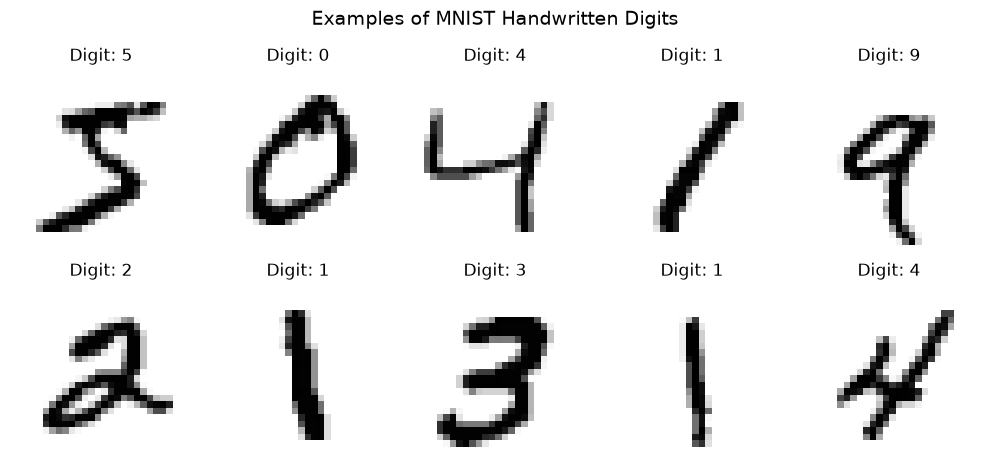

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="binary")
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.suptitle("Examples of MNIST Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

### 1.4 Image Representation — Interpretation

Each MNIST image has 28 × 28 pixels and is stored as a vector of 784 numerical features. Each feature represents the intensity of one pixel, with values ranging from 0 to 255.

A value close to 0 represents a very dark pixel, while a value close to 255 represents a very bright pixel. The `reshape(28, 28)` operation does not change the data; it only converts the 784-element vector back into its original two-dimensional image representation.

For the classical machine learning models used later in this project, the 784-pixel representation can be used directly as numerical input. The MLP models will also receive these 784 features as input, although the neural network can learn nonlinear relationships between them.

## Phase 2 — Data Splitting and Preprocessing

Before training the models, the dataset must be divided into independent training, validation, and test sets.

A stratified split will be used so that the proportion of the ten digit classes remains approximately consistent across all subsets. The test set will remain separate and will only be used for the final model evaluation.

The pixel intensities will then be normalized from their original range of 0–255 to the range 0–1. This provides a consistent numerical scale for the models while preserving the relative intensity information of the images.


### 2.1 Train, Validation, and Test Split

The dataset will be divided into 70% training data, 10% validation data, and 20% test data.

Stratification is applied during both splits to preserve the original class distribution in each subset.


In [17]:
from sklearn.model_selection import train_test_split

# First split: 80% temporary training/validation data and 20% test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Temporary training/validation set:", X_train_val.shape)
print("Test set:", X_test.shape)
print("Temporary training/validation labels:", y_train_val.shape)
print("Test labels:", y_test.shape)

Temporary training/validation set: (56000, 784)
Test set: (14000, 784)
Temporary training/validation labels: (56000,)
Test labels: (14000,)


### 2.2 Training and Validation Split

The temporary training/validation set is divided again into 49,000 training images and 7,000 validation images.

The validation set will be used during model development and hyperparameter selection, while the independent test set will remain untouched until the final evaluation.


In [18]:
# Second split: 70% training and 10% validation of the original dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training set: (49000, 784)
Validation set: (7000, 784)
Test set: (14000, 784)

Training labels: (49000,)
Validation labels: (7000,)
Test labels: (14000,)


### 2.3 Verifying Stratification

The class proportions are compared across the training, validation, and test sets to confirm that stratification preserved a similar distribution of the ten digit classes.


In [19]:
split_distribution = pd.DataFrame({
    "Training": pd.Series(y_train).value_counts(normalize=True),
    "Validation": pd.Series(y_val).value_counts(normalize=True),
    "Test": pd.Series(y_test).value_counts(normalize=True)
}).sort_index()

split_distribution.round(4)

,Training,Validation,Test
0,0.0986,0.0986,0.0986
1,0.1125,0.1126,0.1125
2,0.0999,0.0999,0.0999
3,0.1020,0.1020,0.1020
4,0.0975,0.0974,0.0975
5,0.0902,0.0901,0.0902
6,0.0982,0.0983,0.0982
7,0.1042,0.1041,0.1042
8,0.0975,0.0976,0.0975
9,0.0994,0.0994,0.0994


### 2.3 Stratification — Interpretation

The class proportions are highly consistent across the training, validation, and test sets. The small differences are due only to the discrete number of samples in each subset.

This confirms that stratification successfully preserved the original MNIST class distribution and reduces the risk of introducing sampling bias through the data split.


### 2.4 Pixel Normalization

The original MNIST pixel intensities range from 0 to 255. They will be converted to floating-point values in the range 0 to 1 by dividing each pixel value by 255.

The normalized datasets will be used for model training and evaluation, while the original data will be preserved for visualization and other preprocessing steps.


In [20]:
# Normalize pixel intensities from [0, 255] to [0, 1]
X_train_scaled = X_train.astype("float32") / 255.0
X_val_scaled = X_val.astype("float32") / 255.0
X_test_scaled = X_test.astype("float32") / 255.0

print("Training pixel range:", X_train_scaled.min(), "to", X_train_scaled.max())
print("Validation pixel range:", X_val_scaled.min(), "to", X_val_scaled.max())
print("Test pixel range:", X_test_scaled.min(), "to", X_test_scaled.max())

Training pixel range: 0.0 to 1.0
Validation pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0


In [21]:
print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nTraining dtype:", X_train_scaled.dtype)
print("Validation dtype:", X_val_scaled.dtype)
print("Test dtype:", X_test_scaled.dtype)

Training shape: (49000, 784)
Validation shape: (7000, 784)
Test shape: (14000, 784)

Training dtype: float32
Validation dtype: float32
Test dtype: float32


### Phase 2 — Interpretation

The dataset was divided into 49,000 training images, 7,000 validation images, and 14,000 test images, corresponding to 70%, 10%, and 20% of the original dataset.

Stratification was applied during both splitting steps, preserving the original class distribution across the three subsets.

The pixel intensities were converted from integers in the range 0–255 to `float32` values between 0 and 1. This normalization provides a consistent numerical scale for the models and is particularly important for distance-based models such as KNN and for gradient-based neural network models.

The final shapes and data types confirm that preprocessing did not change the number of features or observations. The test set remains completely independent and will only be used for the final model evaluation in Phase 4.


## Phase 3 — Model Training and Hyperparameter Tuning

Three distinct classification approaches will be developed and compared in this phase:

1. K-Nearest Neighbors (KNN), a distance-based classical machine learning algorithm.
2. Scikit-learn MLPClassifier, a multilayer perceptron neural network.
3. TensorFlow/Keras MLP, a neural network implemented with a deep learning framework.

For each model, at least two hyperparameters will be evaluated using the training and validation sets. The independent test set will remain untouched until Phase 4.

Model performance will be evaluated using validation accuracy during development, while training and prediction time will also be recorded to support the computational cost comparison in the final analysis.


### 3.1 Model 1 — K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a distance-based classification algorithm that predicts the class of a new observation according to the labels of its nearest training examples.

KNN is particularly relevant to this project because the MNIST images contain numerical pixel features and the data were normalized to the range 0–1 in Phase 2. Normalization is important for distance-based algorithms because features with larger numerical scales could otherwise have a disproportionate influence on the distance calculation.

Two main hyperparameters will be evaluated:

* `n_neighbors`: controls how many neighboring observations are considered when making a prediction.
* `weights`: determines whether all neighbors contribute equally (`uniform`) or whether closer neighbors receive greater influence (`distance`).

The validation set will be used to select the best configuration.


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# KNN hyperparameter configurations
knn_configs = [
    {"n_neighbors": 3, "weights": "uniform"},
    {"n_neighbors": 3, "weights": "distance"},
    {"n_neighbors": 5, "weights": "uniform"},
    {"n_neighbors": 5, "weights": "distance"},
    {"n_neighbors": 7, "weights": "uniform"},
    {"n_neighbors": 7, "weights": "distance"},
]

knn_results = []

for config in knn_configs:
    print(
        f"Testing KNN: n_neighbors={config['n_neighbors']}, "
        f"weights={config['weights']}"
    )

    model = KNeighborsClassifier(
        n_neighbors=config["n_neighbors"],
        weights=config["weights"]
    )

    start_time = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    training_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    y_val_pred = model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - start_time

    accuracy = accuracy_score(y_val, y_val_pred)

    knn_results.append({
        "n_neighbors": config["n_neighbors"],
        "weights": config["weights"],
        "validation_accuracy": accuracy,
        "training_time_seconds": training_time,
        "validation_prediction_time_seconds": prediction_time
    })

    print(f"Validation accuracy: {accuracy:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Validation prediction time: {prediction_time:.2f} seconds")
    print()

knn_results_df = pd.DataFrame(knn_results)

knn_results_df.sort_values(
    "validation_accuracy",
    ascending=False
).reset_index(drop=True)

Testing KNN: n_neighbors=3, weights=uniform
Validation accuracy: 0.9719
Training time: 0.01 seconds
Validation prediction time: 1.33 seconds

Testing KNN: n_neighbors=3, weights=distance
Validation accuracy: 0.9723
Training time: 0.01 seconds
Validation prediction time: 1.21 seconds

Testing KNN: n_neighbors=5, weights=uniform
Validation accuracy: 0.9694
Training time: 0.01 seconds
Validation prediction time: 1.25 seconds

Testing KNN: n_neighbors=5, weights=distance
Validation accuracy: 0.9714
Training time: 0.01 seconds
Validation prediction time: 1.25 seconds

Testing KNN: n_neighbors=7, weights=uniform
Validation accuracy: 0.9684
Training time: 0.01 seconds
Validation prediction time: 1.27 seconds

Testing KNN: n_neighbors=7, weights=distance
Validation accuracy: 0.9699
Training time: 0.01 seconds
Validation prediction time: 1.33 seconds



,n_neighbors,weights,validation_accuracy,training_time_seconds,validation_prediction_time_seconds
0,3,distance,0.972286,0.006573,1.214080
1,3,uniform,0.971857,0.010824,1.325420
2,5,distance,0.971429,0.007208,1.254689
3,7,distance,0.969857,0.007118,1.328327
4,5,uniform,0.969429,0.007192,1.248754
5,7,uniform,0.968429,0.006730,1.271800


### 3.1.1 KNN — Hyperparameter Tuning Results

The six KNN configurations were evaluated using the validation set.

The best configuration was `n_neighbors=3` with `weights="distance"`, achieving a validation accuracy of **97.23%**.

Using distance-based weighting produced slightly better results than uniform weighting for the same number of neighbors. Increasing the number of neighbors from 3 to 5 or 7 reduced validation accuracy in this experiment.

The training time was very short because KNN does not build a complex parametric model during training. However, prediction required considerably more computation because the algorithm compares each validation observation with the stored training examples.

The configuration `n_neighbors=3` and `weights="distance"` will therefore be selected as the final KNN configuration.


**Note:** If no hyperparameters were specified, `KNeighborsClassifier` would use `n_neighbors=5` and `weights="uniform"` by default. These default values were included in the tuning experiments as a useful baseline. The selected configuration (`n_neighbors=3`, `weights="distance"`) achieved higher validation accuracy.


In [23]:
# Train the final KNN model using the best validation configuration
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

knn_start_time = time.perf_counter()

knn_model.fit(X_train_scaled, y_train)

knn_training_time = time.perf_counter() - knn_start_time

print("Final KNN model trained.")
print(f"Training time: {knn_training_time:.4f} seconds")

Final KNN model trained.
Training time: 0.0210 seconds
